HERE I AM GOING TO CHOOSE A FEW ALGORITHMS TO TRAIN MY MODEL ON TO SEE WHICH SUPERVISED LEARNING ALGO WILL PERFORM BEST.

Testing among Logistic Regression, Decision Tree, Random Forest and XGBoost and LightGBM

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("kopaScore_dataset.csv")
df.head()

,Unnamed: 0,user_id,monthly_inflow,inflow_volatility,monthly_outflow,airtime_count,prior_defaults,loan_amount,net_cashflow_ratio,loan_to_income_ratio,is_default
0,0,USR_10000,42450.712295,0.226690,29110.784453,16,0,28247.506642,1.458,0.665,0
1,1,USR_10001,32926.035482,0.106661,25465.032387,13,0,29429.696256,1.293,0.894,1
2,2,USR_10002,44715.328072,0.089494,48518.406170,9,0,17452.756607,0.922,0.390,0
3,3,USR_10003,57845.447846,0.101852,57289.780019,17,1,16327.775151,1.010,0.282,0
4,4,USR_10004,31487.699379,0.370578,23341.687219,13,1,16354.199800,1.349,0.519,1


In [3]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,user_id,monthly_inflow,inflow_volatility,monthly_outflow,airtime_count,prior_defaults,loan_amount,net_cashflow_ratio,loan_to_income_ratio,is_default
0,USR_10000,42450.712295,0.226690,29110.784453,16,0,28247.506642,1.458,0.665,0
1,USR_10001,32926.035482,0.106661,25465.032387,13,0,29429.696256,1.293,0.894,1
2,USR_10002,44715.328072,0.089494,48518.406170,9,0,17452.756607,0.922,0.390,0
3,USR_10003,57845.447846,0.101852,57289.780019,17,1,16327.775151,1.010,0.282,0
4,USR_10004,31487.699379,0.370578,23341.687219,13,1,16354.199800,1.349,0.519,1


In [4]:
df["is_default"].value_counts()

,count
is_default,
0,6512
1,3488


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [6]:
x = df.drop(columns=["user_id", "is_default"])
y = df["is_default"]

In [7]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

print(xtrain_scaled.shape, xtest_scaled.shape)

(8000, 8) (2000, 8)


**`LOGISTIC REGRESSION`**





In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model1 = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

scores = cross_val_score(model1, xtrain_scaled, ytrain, cv=cv, scoring="roc_auc")
print(scores)
print(scores.mean())


[0.8378291  0.85858461 0.85131468 0.83312695 0.84656265]
0.8454835957869825


In [10]:
model1.fit(xtrain_scaled, ytrain)
preds = model1.predict(xtest_scaled)
preds

array([0, 1, 0, ..., 0, 0, 0])

In [11]:
print("ACCURACY SCORE",accuracy_score(ytest, preds))
print("ROC_AUC SCORE",roc_auc_score(ytest, preds))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest, preds))

ACCURACY SCORE 0.754
ROC_AUC SCORE 0.7495829647137532

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.84      0.76      0.80      1302
           1       0.63      0.73      0.68       698

    accuracy                           0.75      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.77      0.75      0.76      2000



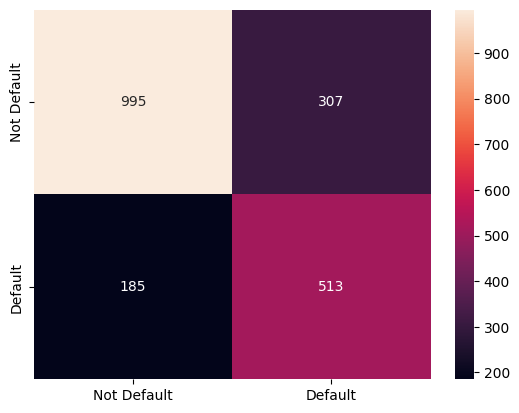

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["Not Default", "Default"]

sns.heatmap(
    confusion_matrix(ytest, preds),
    annot=True,
    xticklabels=labels,
    yticklabels=labels,
    fmt="d"
    )
plt.show()

**`DECISION TREE`**

In [13]:
model2 = DecisionTreeClassifier(max_depth = 3, criterion="gini")
model2.fit(xtrain,ytrain)

DecisionTreeClassifier(max_depth=3)

In [14]:
preds2 = model2.predict(xtest)
preds2

array([0, 1, 0, ..., 0, 0, 0])

In [15]:
print("ACCURACY SCORE",accuracy_score(ytest, preds2))
print("ROC_AUC SCORE",roc_auc_score(ytest, preds2))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest, preds2))

ACCURACY SCORE 0.7605
ROC_AUC SCORE 0.6764829510693269

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.75      0.95      0.84      1302
           1       0.82      0.40      0.54       698

    accuracy                           0.76      2000
   macro avg       0.79      0.68      0.69      2000
weighted avg       0.77      0.76      0.73      2000



**`RANDOM FOREST`**

In [16]:
model3 = RandomForestClassifier(n_estimators=500, max_depth=3, criterion="gini")
model3.fit(xtrain, ytrain)

RandomForestClassifier(max_depth=3, n_estimators=500)

In [17]:
preds3 = model3.predict(xtest)
preds3

array([0, 1, 0, ..., 0, 0, 0])

In [18]:
print("ACCURACY SCORE",accuracy_score(ytest, preds3))
print("ROC_AUC SCORE",roc_auc_score(ytest, preds3))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest, preds3))

ACCURACY SCORE 0.7565
ROC_AUC SCORE 0.6687584452396358

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.74      0.96      0.84      1302
           1       0.83      0.38      0.52       698

    accuracy                           0.76      2000
   macro avg       0.79      0.67      0.68      2000
weighted avg       0.77      0.76      0.73      2000



**`XGBOOST`**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10000 non-null  object 
 1   monthly_inflow        10000 non-null  float64
 2   inflow_volatility     10000 non-null  float64
 3   monthly_outflow       10000 non-null  float64
 4   airtime_count         10000 non-null  int64  
 5   prior_defaults        10000 non-null  int64  
 6   loan_amount           10000 non-null  float64
 7   net_cashflow_ratio    10000 non-null  float64
 8   loan_to_income_ratio  10000 non-null  float64
 9   is_default            10000 non-null  int64  
dtypes: float64(6), int64(3), object(1)
memory usage: 781.4+ KB


In [20]:
core_features = [
    "net_cashflow_ratio",
    "loan_to_income_ratio",
    "prior_defaults",
    "inflow_volatility",
]

In [21]:
xcore = df[core_features]
y = df["is_default"]

In [22]:
xtrain_core, xtest_core, ytrain_core, ytest_core = (train_test_split(xcore, y, test_size=0.2, random_state=42, stratify=y))

In [23]:
ratio = ytrain_core.value_counts()[0] / ytrain_core.value_counts()[1]
ratio

np.float64(1.8673835125448028)

In [24]:
df["is_default"].value_counts()

,count
is_default,
0,6512
1,3488


In [25]:
model4 = XGBClassifier(scale_pos_weight = ratio ,n_estimators=80, max_depth=3, random_state = 42)
model4.fit(xtrain_core, ytrain_core)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=80,
              n_jobs=None, num_parallel_tree=None, ...)

In [26]:
preds4 = model4.predict(xtest_core)
preds4

array([0, 1, 0, ..., 0, 0, 0])

In [27]:
print("ACCURACY SCORE: ",accuracy_score(ytest_core, preds4))
print("ROC_AUC SCORE: ", roc_auc_score(ytest_core, preds4))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest_core, preds4))

ACCURACY SCORE:  0.7745
ROC_AUC SCORE:  0.7606756631851371

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.84      0.81      0.82      1302
           1       0.66      0.71      0.69       698

    accuracy                           0.77      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.78      0.77      0.78      2000



In [28]:
#RANDOM FOREST 2
model5 = RandomForestClassifier(n_estimators=500, max_depth=3, criterion="gini", random_state=42, class_weight="balanced")
model5.fit(xtrain_core, ytrain_core)

RandomForestClassifier(class_weight='balanced', max_depth=3, n_estimators=500,
                       random_state=42)

In [29]:
preds5 = model5.predict(xtest_core)
preds

array([0, 1, 0, ..., 0, 0, 0])

In [30]:
print("ACCURACY SCORE",accuracy_score(ytest_core, preds5))
print("ROC_AUC SCORE",roc_auc_score(ytest_core, preds5))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest_core, preds5))

ACCURACY SCORE 0.7565
ROC_AUC SCORE 0.7558230890100749

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.85      0.76      0.80      1302
           1       0.63      0.75      0.68       698

    accuracy                           0.76      2000
   macro avg       0.74      0.76      0.74      2000
weighted avg       0.77      0.76      0.76      2000



In [31]:
#DECISION TREE 2
model6=DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42, class_weight="balanced")
model6.fit(xtrain_core, ytrain_core)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

In [32]:
preds6 = model6.predict(xtest_core)
preds6

array([1, 1, 0, ..., 0, 0, 0])

In [33]:
print("ACCURACY SCORE",accuracy_score(ytest_core, preds6))
print("ROC_AUC SCORE",roc_auc_score(ytest_core, preds6))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest_core, preds6))

ACCURACY SCORE 0.698
ROC_AUC SCORE 0.7231876020581076

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.86      0.64      0.73      1302
           1       0.55      0.81      0.65       698

    accuracy                           0.70      2000
   macro avg       0.70      0.72      0.69      2000
weighted avg       0.75      0.70      0.70      2000



In [34]:
#Logistic Regression 2
model7 = LogisticRegression(class_weight="balanced", random_state=42)
model7.fit(xtrain_core, ytrain_core)

LogisticRegression(class_weight='balanced', random_state=42)

In [35]:
preds7=model7.predict(xtest_core)
preds7

array([0, 1, 0, ..., 0, 0, 0])

In [36]:
print("ACCURACY SCORE",accuracy_score(ytest_core, preds7))
print("ROC_AUC SCORE",roc_auc_score(ytest_core, preds7))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest_core, preds7))

ACCURACY SCORE 0.78
ROC_AUC SCORE 0.7678907037442946

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1302
           1       0.67      0.73      0.70       698

    accuracy                           0.78      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.79      0.78      0.78      2000



**`LIGHTGBM`**

In [37]:
from lightgbm import LGBMClassifier

In [38]:
lgbm_model = LGBMClassifier(verbosity=-1, max_depth=3, n_estimators=100, random_state=42, scale_pos_weight=ratio)
lgbm_model.fit(xtrain_core, ytrain_core)

LGBMClassifier(max_depth=3, random_state=42,
               scale_pos_weight=np.float64(1.8673835125448028), verbosity=-1)

In [39]:
lgbm_preds = lgbm_model.predict(xtest_core)
lgbm_preds

array([0, 1, 0, ..., 0, 0, 0])

In [40]:
print("ACCURACY SCORE",accuracy_score(ytest_core, lgbm_preds))
print("ROC_AUC SCORE",roc_auc_score(ytest_core, lgbm_preds))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest_core, lgbm_preds))

ACCURACY SCORE 0.773
ROC_AUC SCORE 0.76052051285437

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.84      0.80      0.82      1302
           1       0.66      0.72      0.69       698

    accuracy                           0.77      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.78      0.77      0.78      2000



TRYING TO FINETUNE THE LIGHTGBM MODEL TO SEE IF IT WILL IMPROVE MY METRICS

In [41]:
from sklearn.model_selection import RandomizedSearchCV
lgbm_base = LGBMClassifier(verbosity=-1, scale_pos_weight=ratio, random_state=42)

params = {
    "n_estimators": [50,100,150,200],
    "max_depth": [3,4,5,6,-1],
    "learning_rate":[0.01,0.03,0.05,0.1],
    "num_leaves":[10,20,30,40,50],
    "min_child_samples":[10,20,30,40,50],
    "subsample": [0.7,0.8,0.9,1.0],
    "colsample_bytree": [0.7,0.8,0.9,1.0]
}

lgb_search = RandomizedSearchCV(
    estimator = lgbm_base,
    param_distributions=params,
    n_iter=25,
    cv=5,
    n_jobs=-1,
    scoring="recall",
    random_state=42
    )

lgb_search.fit(xtrain_core, ytrain_core)

best_lgb = lgb_search.best_estimator_

ypred_tuned = best_lgb.predict(xtest_core)

print("ACCURACY SCORE",accuracy_score(ytest_core, ypred_tuned))
print("ROC_AUC SCORE",roc_auc_score(ytest_core, ypred_tuned))
print("\nCLASSIFICATION REPORT: \n",classification_report(ytest_core, ypred_tuned))

ACCURACY SCORE 0.7775
ROC_AUC SCORE 0.7633121184512256

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.84      0.81      0.83      1302
           1       0.67      0.72      0.69       698

    accuracy                           0.78      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.78      0.78      0.78      2000



In [42]:
print(best_lgb)
print(best_lgb.booster_.feature_name())

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.05, min_child_samples=50,
               n_estimators=150, num_leaves=10, random_state=42,
               scale_pos_weight=np.float64(1.8673835125448028), subsample=0.9,
               verbosity=-1)
['net_cashflow_ratio', 'loan_to_income_ratio', 'prior_defaults', 'inflow_volatility']


It didn't work

Now I am going to do some threshold tuning. Default is uaually 0.5. Since we are focusing more on recall than precision, we can lower the threshold, from 0.5 to maybe 0.4 or 0.35

The trade off here is that we will slightly reduce precision, but our main aim is to reduce the loan defaults in the platform.

First, I am going to plot a Threshold vs Recall/Precision curve

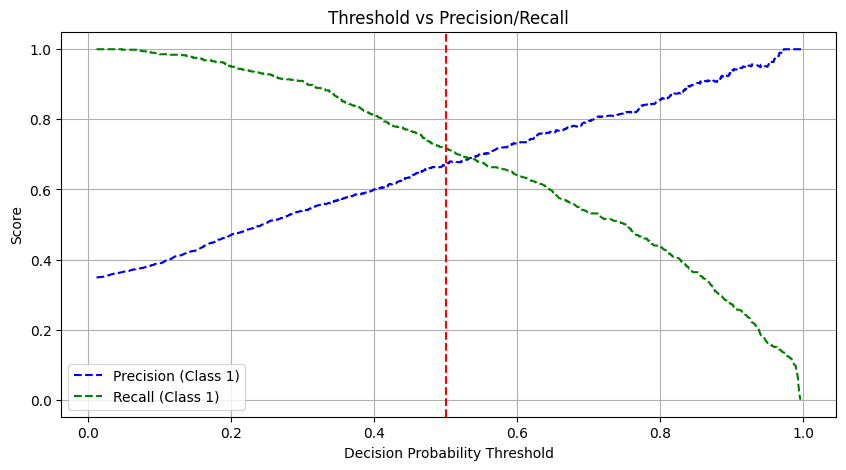

In [43]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores = best_lgb.predict_proba(xtest_core)[:,1]

precisions,recalls,thresholds=precision_recall_curve(ytest_core, y_scores)

plt.figure(figsize=(10,5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (Class 1)")
plt.plot(thresholds, recalls[:-1], "g--", label="Recall (Class 1)")
plt.xlabel("Decision Probability Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision/Recall")
plt.legend()
plt.grid(True)
plt.axvline(x=0.5, color="red", linestyle="--", label="Default Threshold(0.5)")
plt.show()

So based on this plot here we can see the proper threshold that balances out precision and recall is at around 0.54.

In my case here, I am looking for a higher recall cause we want to catch more actual defaults. My goal is to protect the capital, not to approve more loans

So I am going to reduce it to 0.4

In [44]:
y_proba = best_lgb.predict_proba(xtest_core)[:,1]

custom_threshold = 0.4

ypred_custom = (y_proba>=0.4).astype(int)

print("ACCURACY SCORE: ", accuracy_score(ytest_core, ypred_custom))
print("ROC_AUC SCORE: ", roc_auc_score(ytest_core, ypred_custom))
print("\nCLASSIFICATION REPORT: \n", classification_report(ytest_core, ypred_custom))

ACCURACY SCORE:  0.746
ROC_AUC SCORE:  0.761715500508365

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.88      0.71      0.78      1302
           1       0.60      0.81      0.69       698

    accuracy                           0.75      2000
   macro avg       0.74      0.76      0.74      2000
weighted avg       0.78      0.75      0.75      2000



In [45]:
yproba_logreg = model1.predict_proba(xtest_scaled)[:,1]

custom_threshold = 0.4

ypred_custom_logreg = (yproba_logreg>=0.4).astype(int)

print("ACCURACY SCORE: ", accuracy_score(ytest, ypred_custom_logreg))
print("ROC_AUC SCORE: ", roc_auc_score(ytest, ypred_custom_logreg))
print("\nCLASSIFICATION REPORT: \n", classification_report(ytest, ypred_custom_logreg))

ACCURACY SCORE:  0.734
ROC_AUC SCORE:  0.760141990061576

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.89      0.67      0.77      1302
           1       0.58      0.85      0.69       698

    accuracy                           0.73      2000
   macro avg       0.74      0.76      0.73      2000
weighted avg       0.78      0.73      0.74      2000



I have decided to go with the LightGBM Model for this. Nimefungia hapo hii story

Let me do a Confusion matrix analysis to prove my point that it's better to lose a few good borrowers than allowing a lot of defaults through.

In [46]:
LOAN_AMOUNT = 10000
INTEREST_RATE = 0.1
PROFIT_PER_PAID_LOAN = LOAN_AMOUNT * INTEREST_RATE
LOSS_PER_DEFAULT = LOAN_AMOUNT

def evaluate_financials(threshold, ytrue, yprobs):
  #Apply threshold
  ypred = (yprobs >= threshold).astype(int)

  #confusion matrix values
  #tn --> Approved and Paid
  #fp --> Rejected but was a good borrower
  #fn --> Approved but defaulted
  #tp --> Rejected and Defaulted

  tn, fp, fn, tp = confusion_matrix(ytrue, ypred).ravel()

  #here i calculate monetary outcomes
  interest_earned = tn*PROFIT_PER_PAID_LOAN
  capital_lost=fn*LOSS_PER_DEFAULT
  capital_saved=tp*PROFIT_PER_PAID_LOAN
  opportunity_cost=fp*PROFIT_PER_PAID_LOAN

  #total profit
  total_profit = interest_earned + capital_saved - opportunity_cost - capital_lost

  return{
     "Threshold": threshold,
        "True Negatives (Approved & Paid)": tn,
        "False Positives (Rejected Good)": fp,
        "False Negatives (Approved & Defaulted)": fn,
        "True Positives (Blocked Default)": tp,
        "Interest Earned (KES)": interest_earned,
        "Capital Lost to Defaults (KES)": capital_lost,
        "Capital Saved (KES)": capital_saved,
        "Total Profit (KES)": total_profit,
        "Opportunity Cost (KES)": opportunity_cost
     }

#Nacompare thresholds
results50 = evaluate_financials(0.5, ytest_core, y_proba)
results40 = evaluate_financials(0.4, ytest_core, y_proba)

#displaying the comparisons
df_financials = pd.DataFrame([results50, results40])
print(df_financials.T)

                                                0          1
Threshold                                     0.5        0.4
True Negatives (Approved & Paid)           1055.0      924.0
False Positives (Rejected Good)             247.0      378.0
False Negatives (Approved & Defaulted)      198.0      130.0
True Positives (Blocked Default)            500.0      568.0
Interest Earned (KES)                   1055000.0   924000.0
Capital Lost to Defaults (KES)          1980000.0  1300000.0
Capital Saved (KES)                      500000.0   568000.0
Total Profit (KES)                      -672000.0  -186000.0
Opportunity Cost (KES)                   247000.0   378000.0


So as you can see here, even though we are earning less interest when we reduce the threshold, we are losing a lot of capital due to defaults.

**`EXPORT MODEL`**

In [47]:
import joblib

joblib.dump(best_lgb, "lightgbm_model.joblib")

#i am going to export the core fetaures too
core_features=[
    "loan_to_income_ratio",
    "net_cashflow_ratio",
    "inflow_volatility",
    "prior_defaults",
]
joblib.dump(core_features, "core_features.joblib")

print("Model and core features successfully exported")

Model and core features successfully exported
